# Notebook for training models

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import ipywidgets as widgets
from ipywidgets import interact

## Data loading and visualization

In [2]:
# 1. Load Data
with open('data/final_models_input/train_dataset.pkl', 'rb') as f:
    train_data = pickle.load(f)
    
with open('data/final_models_input/test_dataset.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train_raw = train_data['X'] # Shape: (N, 1500, 4)
X_test_raw = test_data['X']

# 1. Define Feature Names (Based on your input order)
# Adjust these if your order was different!
feature_map = {
    "0: Active Power": 0,
    "1: Guide Vane Position": 1,
    "2: Water Pressure Downstream": 2,
    "3: Water Pressure Upstream": 3
}

# 2. Extract Durations for Visualization
# We assume train_data was loaded as per your snippet
train_durations = train_data['durations']
# train_durations = test_data['durations']

def inspect_training_sample(sample_index, feature_name):
    # Get Feature Index
    feat_idx = feature_map[feature_name]
    
    # Get Data
    signal_data = X_train_raw[sample_index, :, feat_idx]
    
    # Get Original Duration (to visualize where padding starts)
    # The duration is in seconds, data is 10Hz, so index = duration * 10
    original_end_index = int(train_durations[sample_index] * 10)
    
    # --- Plotting ---
    plt.figure(figsize=(12, 5))
    
    # Plot the signal
    plt.plot(signal_data, color='blue', linewidth=1.5, label='Sensor Signal')
    
    # TODO: Fix this plotting to show the actual end of real data, right now it is wrong!!
    # Plot the "End of Real Data" line
    if original_end_index < 1500:
        plt.axvline(x=original_end_index, color='red', linestyle='--', linewidth=2, label='End of Real Data / Start of Padding')
        # Highlight the padded area
        plt.axvspan(original_end_index, 1500, color='yellow', alpha=0.1, label='Padded Region')
        
    plt.title(f"Sample #{sample_index}: {feature_name}", fontsize=14)
    plt.ylabel("Value (Raw Scale)")
    plt.xlabel("Time Steps (0.1s)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

# 3. Create Interactive Widgets
interact(inspect_training_sample, 
         sample_index=widgets.IntSlider(min=0, max=len(X_train_raw)-1, step=1, value=0, description='Sample ID'),
         feature_name=widgets.Dropdown(options=feature_map.keys(), value="2: Water Pressure Downstream", description='Feature'));

interactive(children=(IntSlider(value=0, description='Sample ID', max=2459), Dropdown(description='Feature', i…

##  Data Loading & Normalization

In [6]:
# 1. Load the Data
with open('data/final_models_input/train_dataset.pkl', 'rb') as f:
    train_data = pickle.load(f)
    
with open('data/final_models_input/test_dataset.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_train_raw = train_data['X'] # (N, 1500, 4)
X_test_raw = test_data['X']   # (N, 1500, 4)

# 2. Normalization (MinMax 0-1)
# We flatten the time dimension to fit the scaler, then reshape back
N, T, F = X_train_raw.shape
scaler = MinMaxScaler()

# Flatten -> Fit -> Reshape
X_train_flat = X_train_raw.reshape(-1, F)
scaler.fit(X_train_flat)
X_train_scaled = scaler.transform(X_train_flat).reshape(N, T, F)

# Apply same scaler to Test data
X_test_flat = X_test_raw.reshape(-1, F)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test_raw.shape[0], T, F)

# 3. Convert to PyTorch Tensors
tensor_x = torch.Tensor(X_train_scaled) # Shape: [N, 1500, 4]

# A. Create the Full Dataset first
full_dataset = TensorDataset(tensor_x)

# B. Calculate split sizes
val_size = int(len(tensor_x) * 0.15)
train_size = len(tensor_x) - val_size

# C. Split the DATASET (not the tensor)
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# D. Create Loaders
# Note: We pass 'train_subset' directly, no TensorDataset() wrapper needed here
batch_size = 64
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

print(f"Data Loaded Successfully.")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")

Data Loaded Successfully.
Train batches: 33
Val batches: 6


## Define the LSTM Autoencoder

In [30]:
# class Encoder(nn.Module):
#     def __init__(self, n_features, embedding_dim):
#         super(Encoder, self).__init__()
#         # Layer 1
#         self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=128, num_layers=1, batch_first=True)
#         # Layer 2 (Compression)
#         self.lstm2 = nn.LSTM(input_size=128, hidden_size=embedding_dim, num_layers=1, batch_first=True)
        
#     def forward(self, x):
#         # x: (batch, seq_len, features)
#         x, (_, _) = self.lstm1(x)
#         _, (hidden, _) = self.lstm2(x)
#         # We want the final hidden state of the last layer
#         return hidden[-1] # Shape: (batch, embedding_dim)

# class Decoder(nn.Module):
#     def __init__(self, seq_len, input_dim, n_features):
#         super(Decoder, self).__init__()
#         self.seq_len = seq_len
#         self.input_dim = input_dim
#         self.hidden_dim = 128
        
#         # Layer 1 (Unpacking)
#         self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=128, num_layers=1, batch_first=True)
#         # Layer 2 (Refinement)
#         self.lstm2 = nn.LSTM(input_size=128, hidden_size=64, num_layers=1, batch_first=True)
#         # Output Layer (Map back to 4 features)
#         self.output_layer = nn.Linear(64, n_features)

#     def forward(self, x):
#         # x is the latent vector: (batch, embedding_dim)
#         # Repeat vector to match sequence length
#         x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        
#         x, _ = self.lstm1(x)
#         x, _ = self.lstm2(x)
        
#         # Linear layer applied to every time step
#         x = self.output_layer(x)
#         return x

# class RecurrentAutoencoder(nn.Module):
#     def __init__(self, seq_len, n_features, embedding_dim=64):
#         super(RecurrentAutoencoder, self).__init__()
#         self.encoder = Encoder(n_features, embedding_dim)
#         self.decoder = Decoder(seq_len, embedding_dim, n_features)

#     def forward(self, x):
#         latent = self.encoder(x)
#         reconstruction = self.decoder(latent)
#         return reconstruction

class Encoder(nn.Module):
    def __init__(self, n_features, embedding_dim):
        super(Encoder, self).__init__()
        # 1. Unidirectional LSTM (bidirectional=False)
        # We increase hidden_size to 128 to keep capacity high
        self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=256, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=embedding_dim, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
    def forward(self, x):
        x, (_, _) = self.lstm1(x)
        _, (hidden, _) = self.lstm2(x)
        return hidden[-1]

class Decoder(nn.Module):
    def __init__(self, seq_len, input_dim, n_features):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        
        # Decoder matches Encoder
        self.lstm1 = nn.LSTM(input_size=input_dim, hidden_size=256, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, 
                             num_layers=1, batch_first=True, bidirectional=False)
        
        self.output_layer = nn.Linear(256, n_features)

    def forward(self, x):
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = self.output_layer(x)
        return x
    
class RecurrentAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(RecurrentAutoencoder, self).__init__()
        self.encoder = Encoder(n_features, embedding_dim)
        self.decoder = Decoder(seq_len, embedding_dim, n_features)

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        return reconstruction


## Training

Training on device: cuda
Starting Training...
Epoch 1/50 | Train Loss: 0.132154 | Val Loss: 0.134923
Epoch 2/50 | Train Loss: 0.083565 | Val Loss: 0.115245
Epoch 3/50 | Train Loss: 0.078201 | Val Loss: 0.113345
Epoch 4/50 | Train Loss: 0.070762 | Val Loss: 0.096049
Epoch 5/50 | Train Loss: 0.064638 | Val Loss: 0.095889
Epoch 6/50 | Train Loss: 0.065043 | Val Loss: 0.091383
Epoch 7/50 | Train Loss: 0.062125 | Val Loss: 0.092049
Epoch 8/50 | Train Loss: 0.061864 | Val Loss: 0.092872
Epoch 9/50 | Train Loss: 0.063188 | Val Loss: 0.093373
Epoch 10/50 | Train Loss: 0.061963 | Val Loss: 0.089849
Epoch 11/50 | Train Loss: 0.060705 | Val Loss: 0.157474
Epoch 12/50 | Train Loss: 0.072224 | Val Loss: 0.093748
Epoch 13/50 | Train Loss: 0.064401 | Val Loss: 0.092953
Epoch 14/50 | Train Loss: 0.061454 | Val Loss: 0.088711
Epoch 15/50 | Train Loss: 0.065053 | Val Loss: 0.099696
Epoch 16/50 | Train Loss: 0.063006 | Val Loss: 0.089805
Epoch 17/50 | Train Loss: 0.060223 | Val Loss: 0.087462
Epoch 18/50

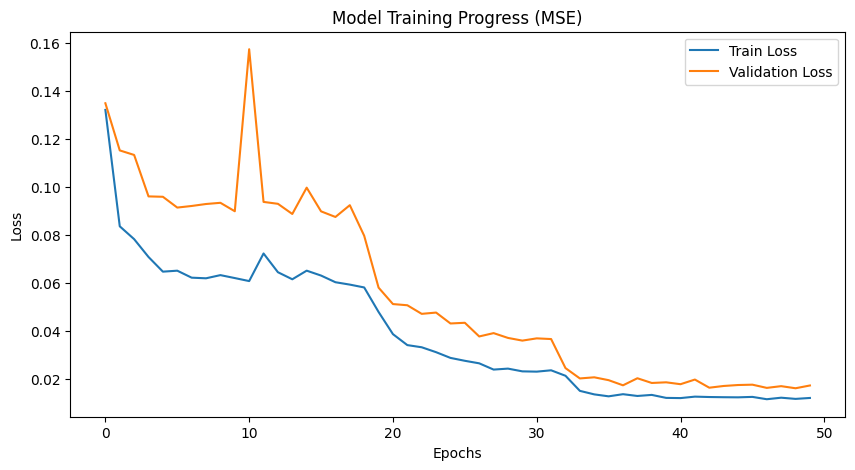

In [25]:
# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

# Hyperparameters
# SEQ_LEN = 1500
SEQ_LEN = 300
N_FEATURES = 4
EMBEDDING_DIM = 128 # Size of the compressed representation
LR = 1e-3
EPOCHS = 50

# Initialize Model
model = RecurrentAutoencoder(SEQ_LEN, N_FEATURES, EMBEDDING_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
# criterion = nn.MSELoss()
criterion = nn.L1Loss() # MAE Loss, sharper reconstructions

# Training History
history = {'train_loss': [], 'val_loss': []}

print("Starting Training...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    for batch in train_loader:
        # Input is (batch, 1500, 4)
        for batch in train_loader:
            x = batch[0].to(device)
            
            # === CRITICAL CHANGE ===
            # Take every 5th point. 
            # New Shape: (Batch, 300, 4)
            x = x[:, ::5, :]  
        
        # Forward
        output = model(x)
        loss = criterion(output, x) # Compare Input vs Output
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * x.size(0)
        
    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            x = x[:, ::5, :]
            output = model(x)
            loss = criterion(output, x)
            val_loss += loss.item() * x.size(0)
            
    # Calculate Average Losses
    train_loss = train_loss / len(train_subset)
    val_loss = val_loss / len(val_subset)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Model Training Progress (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Save model

In [27]:
# 1. Save Model Weights
torch.save(model.state_dict(), 'lstm_uni_autoencoder_model.pth')

# 2. Save Scaler (Important!)
with open('data/final_models_input/uni_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model and Scaler saved successfully.")

Model and Scaler saved successfully.


## Visual check

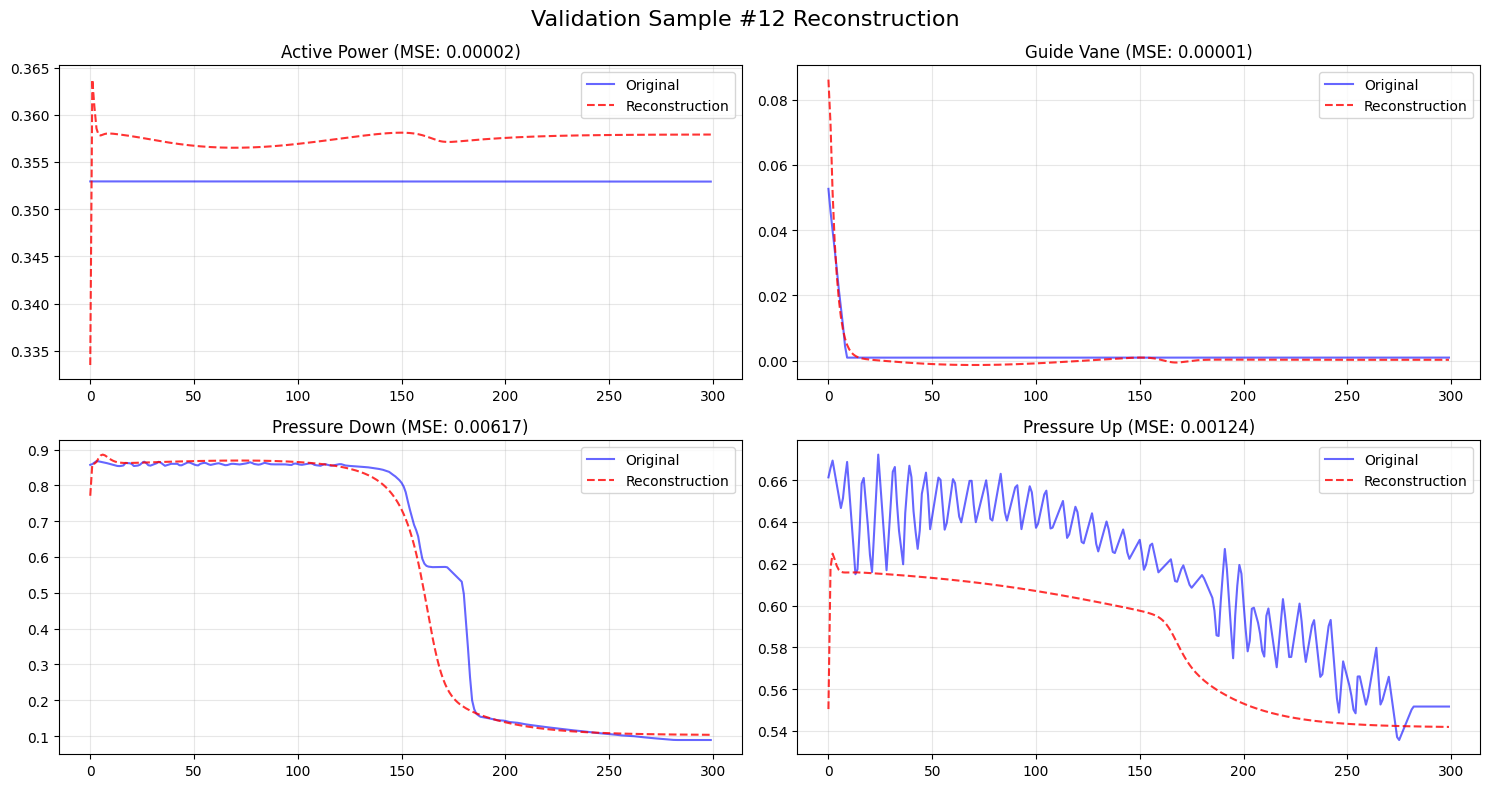

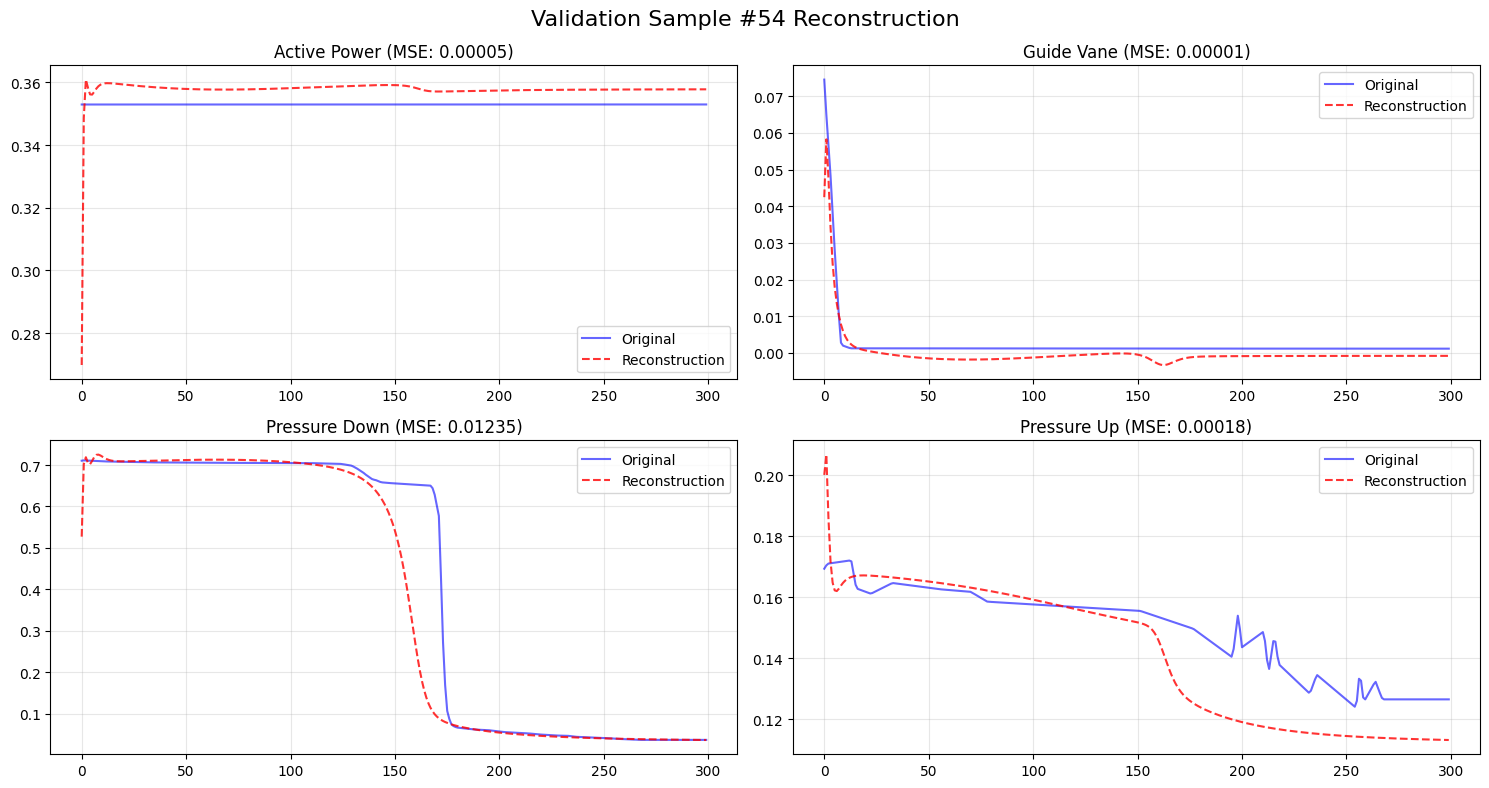

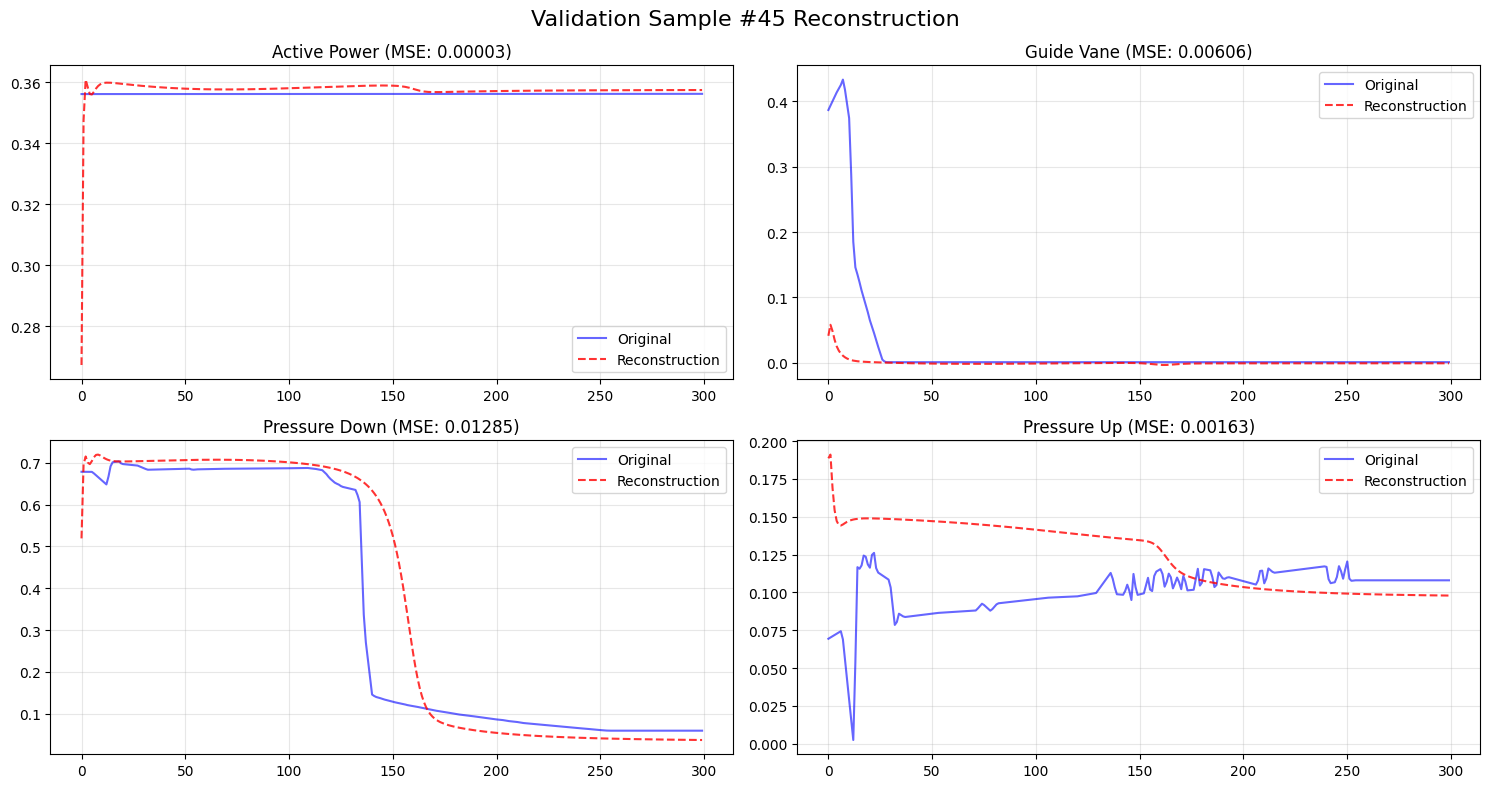

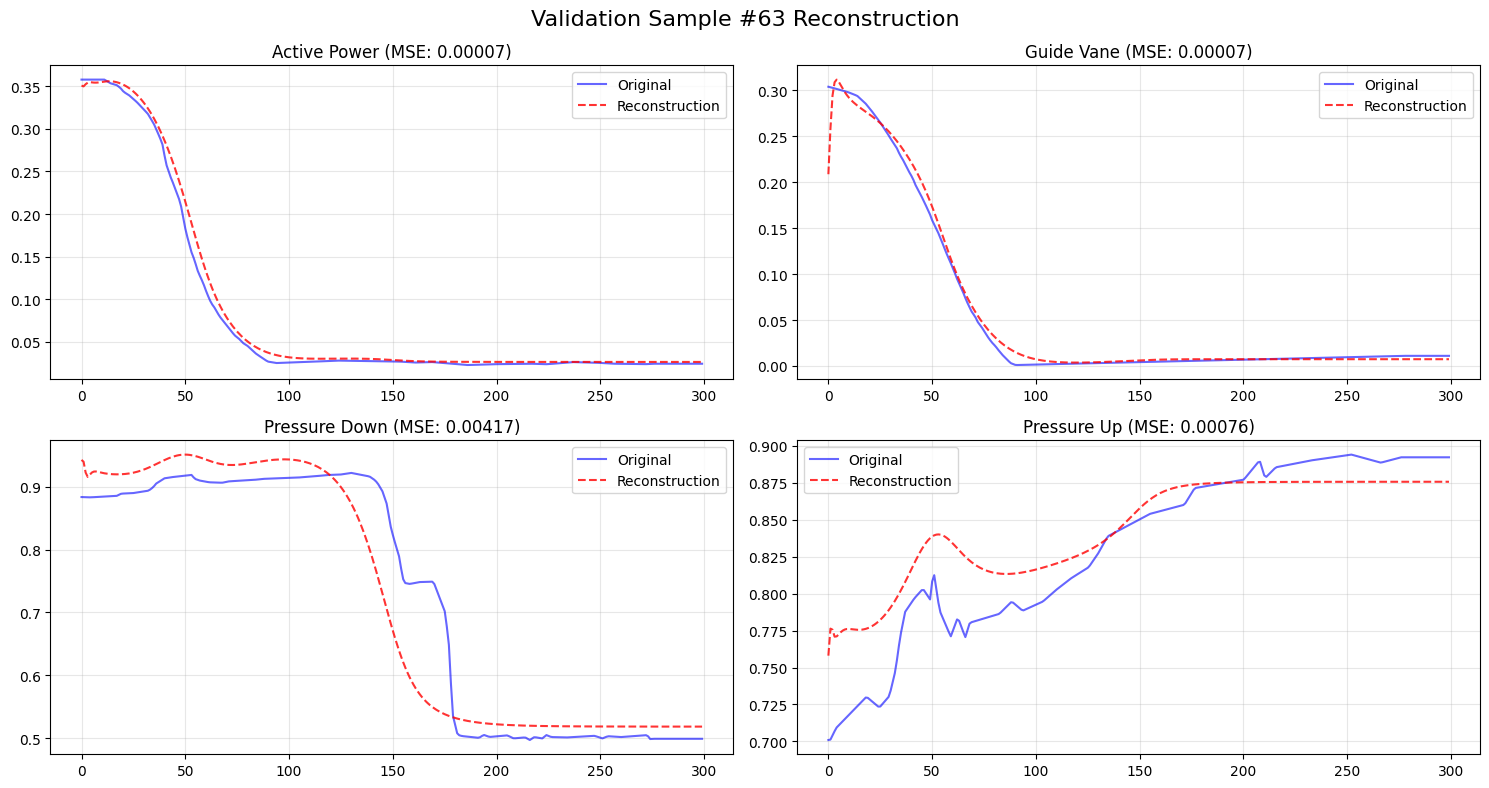

In [29]:
# 1. Get a batch from validation loader
model.eval()
with torch.no_grad():
    x_val_batch = next(iter(val_loader))[0].to(device)
    x_val_small = x_val_batch[:, ::5, :]
    recon_batch = model(x_val_small)
    
    # Move to CPU for plotting
    x_val = x_val_small.cpu().numpy()
    recon = recon_batch.cpu().numpy()

# 2. Plotting Function
def check_reconstruction(idx):
    plt.figure(figsize=(15, 8))
    
    features = ["Active Power", "Guide Vane", "Pressure Down", "Pressure Up"]
    
    for i, name in enumerate(features):
        plt.subplot(2, 2, i+1)
        
        # Plot Original
        plt.plot(x_val[idx, :, i], label='Original', color='blue', alpha=0.6)
        # Plot Reconstruction
        plt.plot(recon[idx, :, i], label='Reconstruction', color='red', linestyle='--', alpha=0.8)
        
        # Calculate Error for this specific feature
        mse_feat = np.mean((x_val[idx, :, i] - recon[idx, :, i])**2)
        plt.title(f"{name} (MSE: {mse_feat:.5f})")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
    plt.suptitle(f"Validation Sample #{idx} Reconstruction", fontsize=16)
    plt.tight_layout()
    plt.show()

# 3. Check a few samples
check_reconstruction(12) # Change index to see others
check_reconstruction(54)
check_reconstruction(45)
check_reconstruction(63) 

### Evaluation on test data

In [31]:
# --- 1. Load and Process Test Data ---
with open('data/final_models_input/test_dataset.pkl', 'rb') as f:
    test_data = pickle.load(f)

X_test_raw = test_data['X'] # Shape (N, 1500, 4)

# Scale (Using your existing fitted scaler)
N, T, F = X_test_raw.shape
X_test_flat = X_test_raw.reshape(-1, F)
X_test_scaled = scaler.transform(X_test_flat).reshape(N, T, F)

# Downsample (Critical: Match the training sequence length of 300)
X_test_final = X_test_scaled[:, ::5, :] 

# Convert to Tensor
test_tensor = torch.FloatTensor(X_test_final).to(device)


In [32]:

# --- 2. Run Inference ---
model.eval()
with torch.no_grad():
    # Pass all test data through model
    recon_test = model(test_tensor)
    
    # Calculate Anomaly Scores (L1 Loss per sample)
    # Shape: (N_samples,)
    test_losses = torch.mean(torch.abs(test_tensor - recon_test), dim=(1, 2)).cpu().numpy()
    
    # Move data to CPU for plotting
    X_test_np = X_test_final # Already numpy
    recon_test_np = recon_test.cpu().numpy()


In [33]:

# --- 3. Visualization Function ---
def view_test_sample(idx):
    loss = test_losses[idx]
    
    plt.figure(figsize=(15, 8))
    features = ["Active Power", "Guide Vane", "Pressure Down", "Pressure Up"]
    
    for i, name in enumerate(features):
        plt.subplot(2, 2, i+1)
        
        # Plot Original
        plt.plot(X_test_np[idx, :, i], label='Original', color='black', alpha=0.7)
        # Plot Reconstruction
        plt.plot(recon_test_np[idx, :, i], label='Reconstruction', color='red', linestyle='--')
        
        # Fill error
        plt.fill_between(range(300), X_test_np[idx, :, i], recon_test_np[idx, :, i], color='red', alpha=0.1)
        
        plt.title(f"{name}")
        plt.legend()
        plt.grid(True, alpha=0.3)
        
    plt.suptitle(f"Test Sample #{idx} | Anomaly Score: {loss:.6f}", fontsize=16)
    plt.tight_layout()
    plt.show()


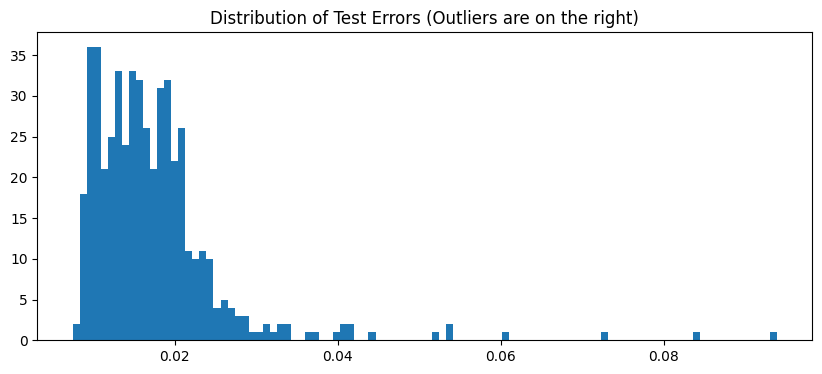

Visualizing Top Detected Anomalies:


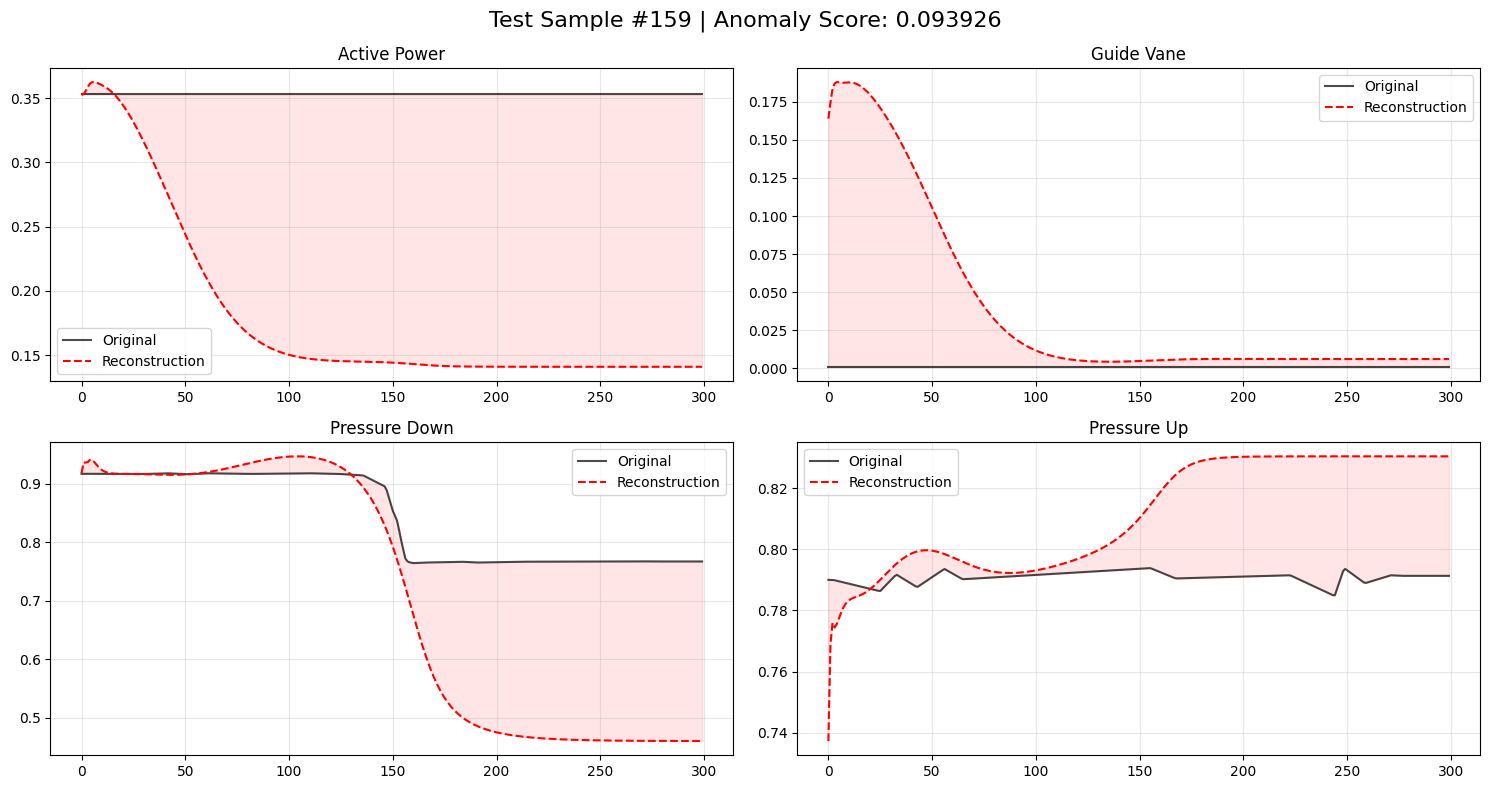

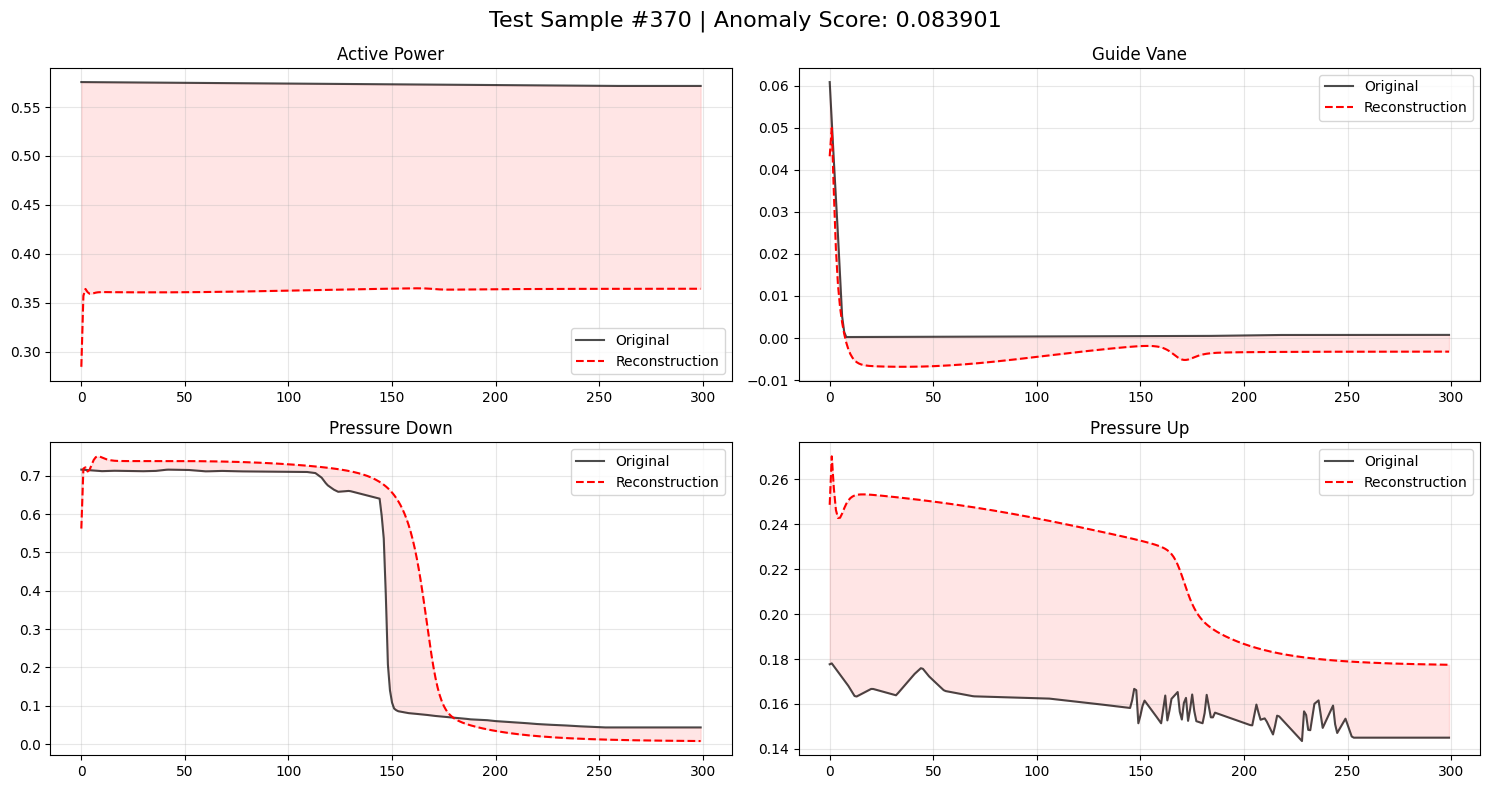

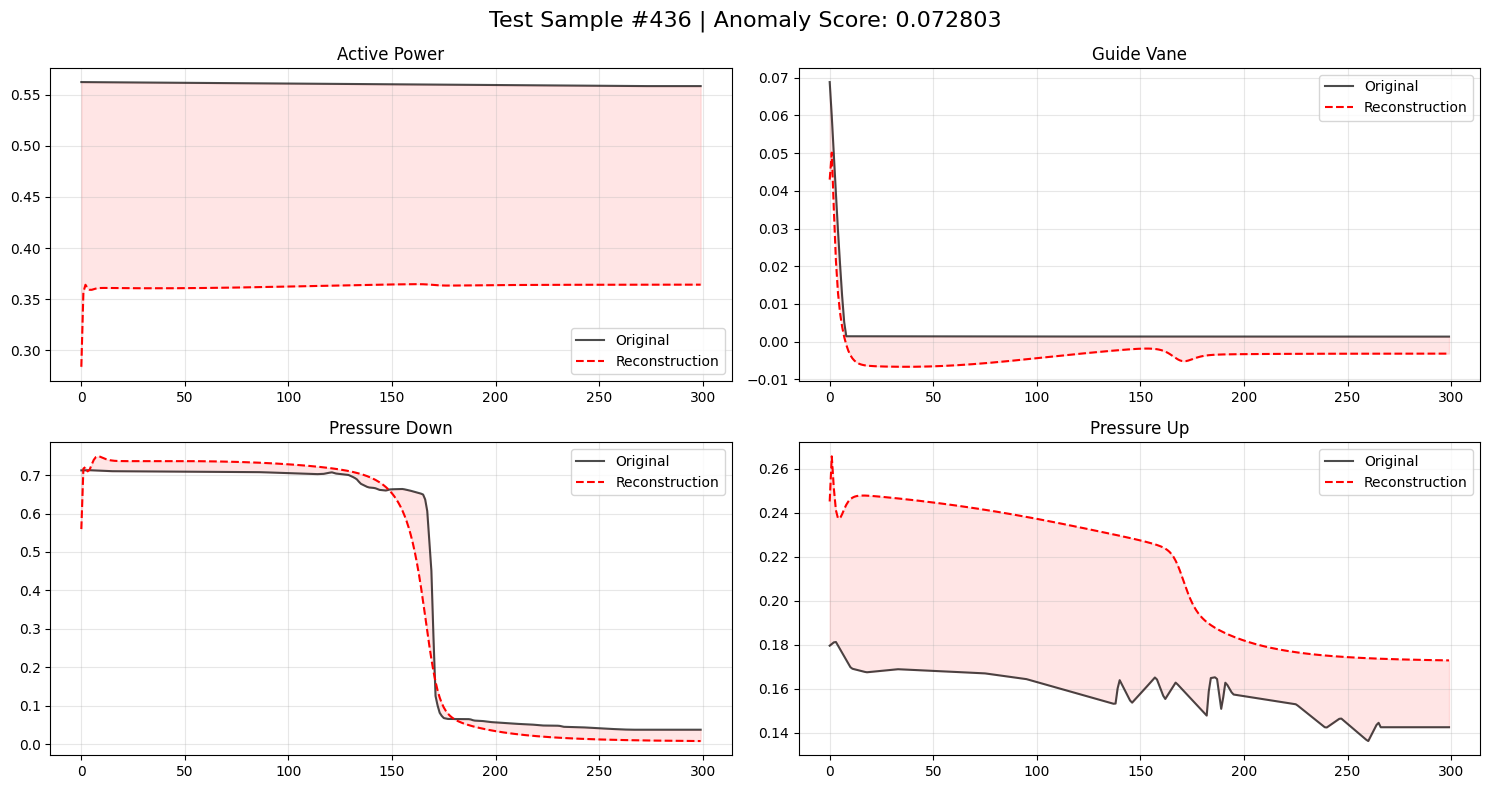

Visualizing a Low-Error (Normal) Sample:


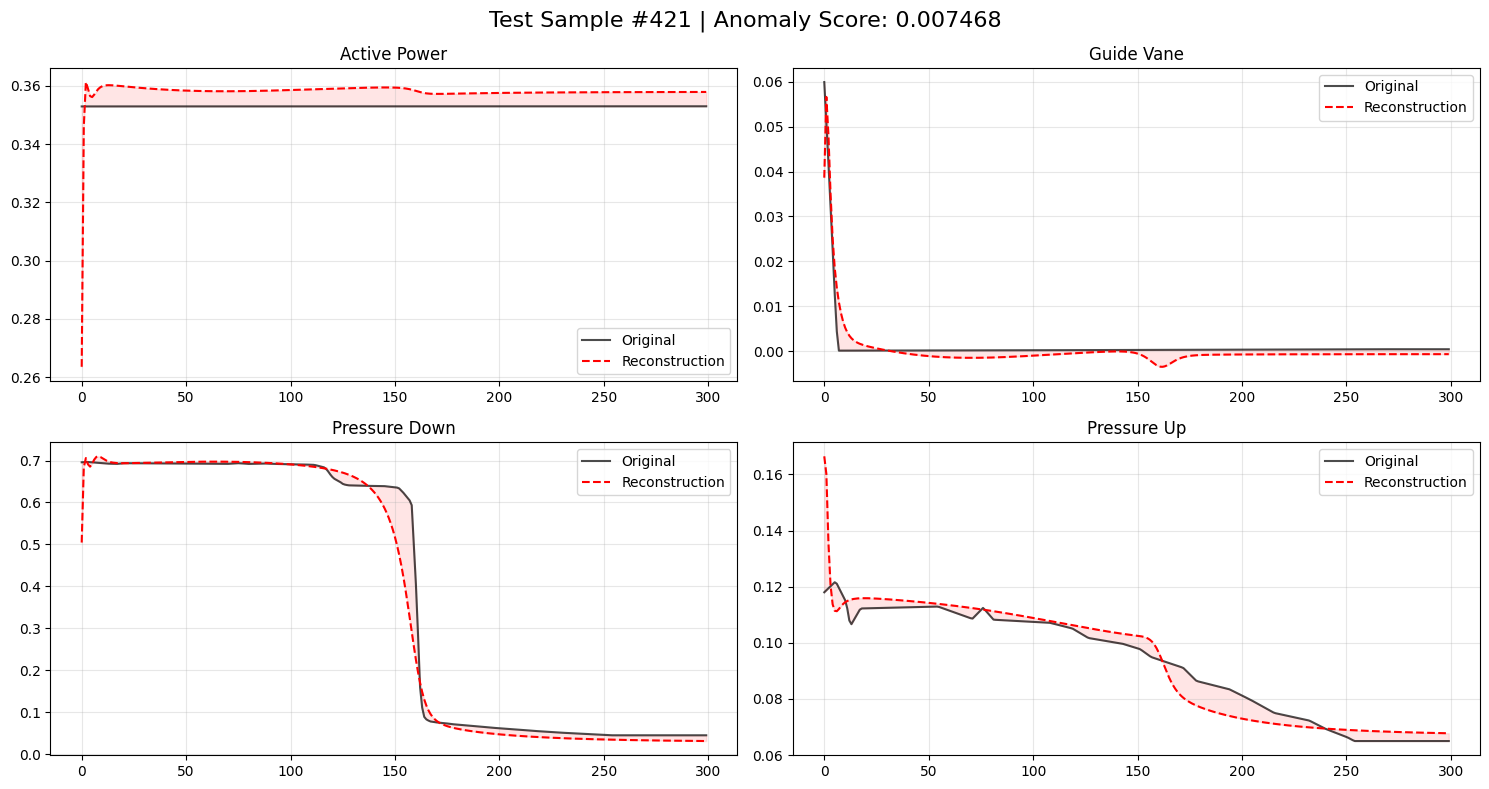

In [34]:

# --- 4. Inspect Results ---

# A. Histogram to see separation
plt.figure(figsize=(10,4))
plt.hist(test_losses, bins=100)
plt.title("Distribution of Test Errors (Outliers are on the right)")
plt.show()

# B. Find the Top 3 "Worst" Reconstructions (Likely Anomalies)
sorted_indices = np.argsort(test_losses)[::-1] # Sort descending
top_anomalies = sorted_indices[:3]

print("Visualizing Top Detected Anomalies:")
for idx in top_anomalies:
    view_test_sample(idx)

# C. Check a Random Normal Sample (from the "good" pile)
print("Visualizing a Low-Error (Normal) Sample:")
best_idx = sorted_indices[-1]
view_test_sample(best_idx)